# **Predictive Analytics Using Historical Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Predictive Analytics Using Historical Data-Dataset.csv")

**Display the first 5 rows**

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



**Check dataset size**

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9800
Columns: 18


**Column names**

In [7]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


**Data types**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

**Missing values**

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Duplicate rows**

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [12]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

In [13]:
df[['Order Date', 'Sales']].head()

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680


**Sorting**

In [14]:
df = df.sort_values('Order Date')

**Monthly sales**

In [15]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

In [16]:
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

In [17]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


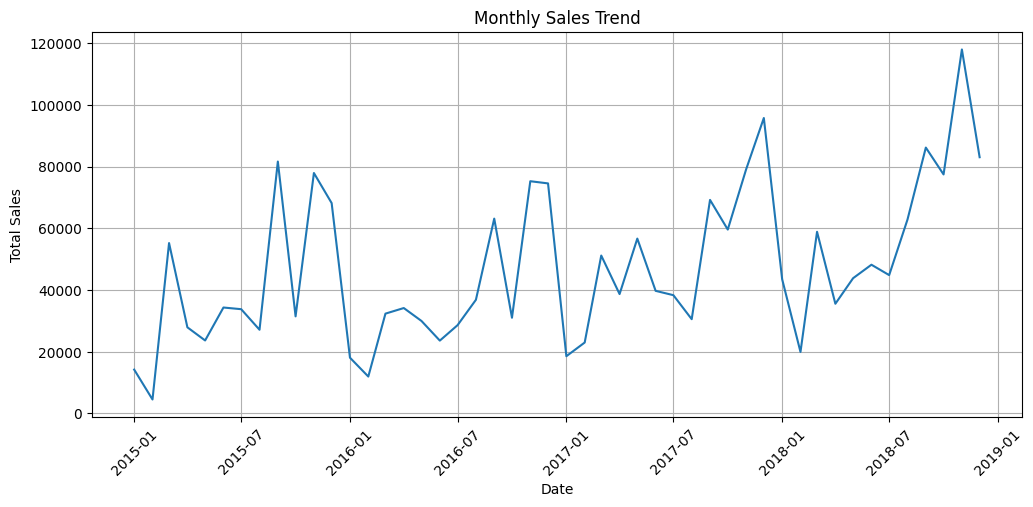

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# **Time-based feature**

In [19]:
monthly_sales['Month_Number'] = np.arange(len(monthly_sales))

In [20]:
monthly_sales.head()

,Order Date,Sales,Month_Number
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


**Createing X and y**

In [21]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

# **Split the data into training and testing**

In [22]:
split = int(len(monthly_sales) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 38
Testing data: 10


**Train the Linear Regression model**

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

**Make predictions**

In [24]:
y_pred = model.predict(X_test)

In [25]:
prediction_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

prediction_df.head()

,Actual Sales,Predicted Sales
0,58863.4128,55563.601236
1,35541.9101,56249.882764
2,43825.9822,56936.164291
3,48190.7277,57622.445819
4,44825.1040,58308.727347


**Evaluate the model**

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 18560.28591345771
R² Score: 0.03323365449775528


**Visualize Actual vs Predicted Sales**

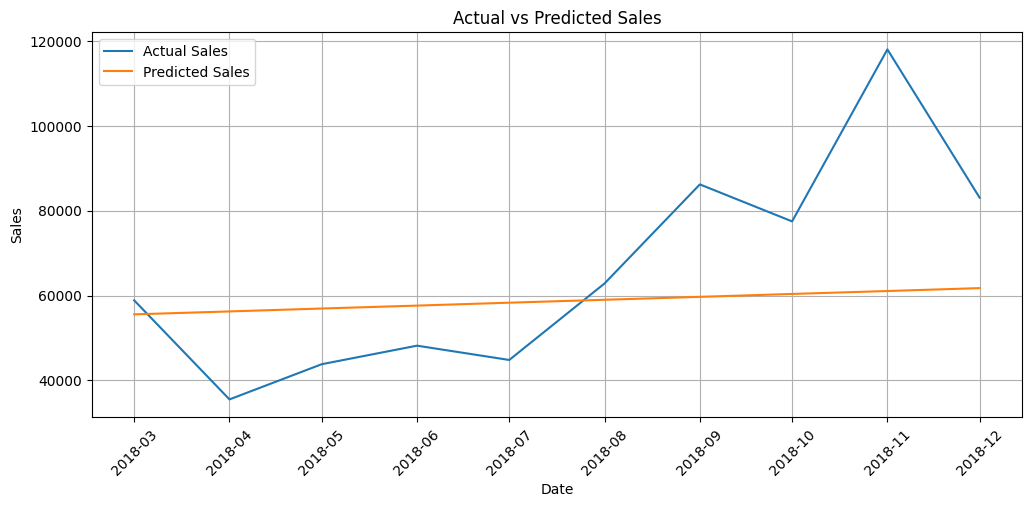

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Order Date'][split:],
    y_test,
    label='Actual Sales'
)

plt.plot(
    monthly_sales['Order Date'][split:],
    y_pred,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**To create future months**

In [29]:
last_month_number = monthly_sales['Month_Number'].max()

future_month_numbers = np.arange(
    last_month_number + 1,
    last_month_number + 7
)

future_X = pd.DataFrame({
    'Month_Number': future_month_numbers
})

future_predictions = model.predict(future_X)

**To create future dates**

In [30]:
last_date = monthly_sales['Order Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

**To create the future prediction table**

In [31]:
future_sales = pd.DataFrame({
    'Date': future_dates,
    'Predicted Sales': future_predictions
})

future_sales

,Date,Predicted Sales
0,2019-01-01,62426.416513
1,2019-02-01,63112.698041
2,2019-03-01,63798.979569
3,2019-04-01,64485.261097
4,2019-05-01,65171.542624
5,2019-06-01,65857.824152


**Visualize Historical + Future Sales**

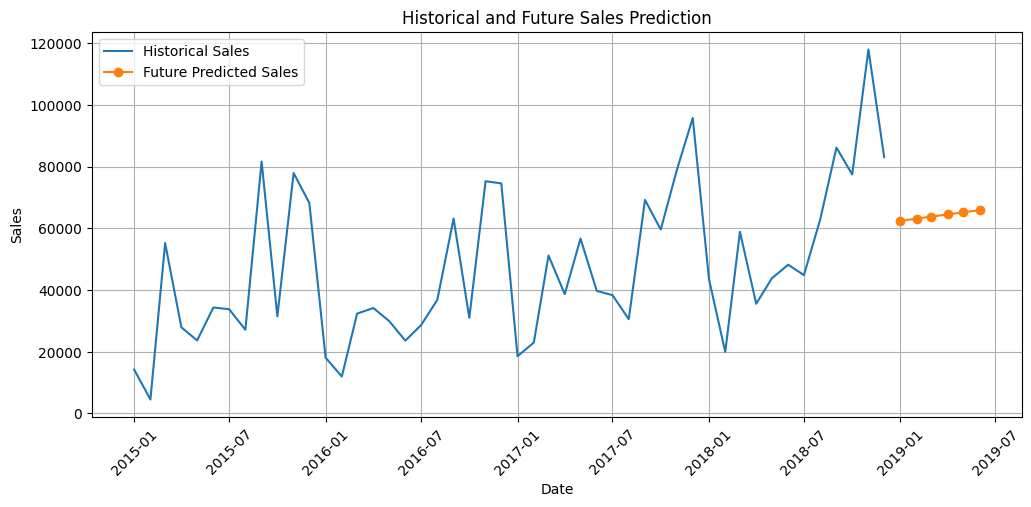

In [32]:
plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    label='Historical Sales'
)

# Future predictions
plt.plot(
    future_sales['Date'],
    future_sales['Predicted Sales'],
    marker='o',
    label='Future Predicted Sales'
)

plt.title('Historical and Future Sales Prediction')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**Print the forecast clearly**

In [33]:
print("Future Sales Forecast:")
print()

for date, sales in zip(
    future_sales['Date'],
    future_sales['Predicted Sales']
):
    print(f"{date.strftime('%B %Y')}: ${sales:,.2f}")

Future Sales Forecast:

January 2019: $62,426.42
February 2019: $63,112.70
March 2019: $63,798.98
April 2019: $64,485.26
May 2019: $65,171.54
June 2019: $65,857.82


**Find the highest-selling category**

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


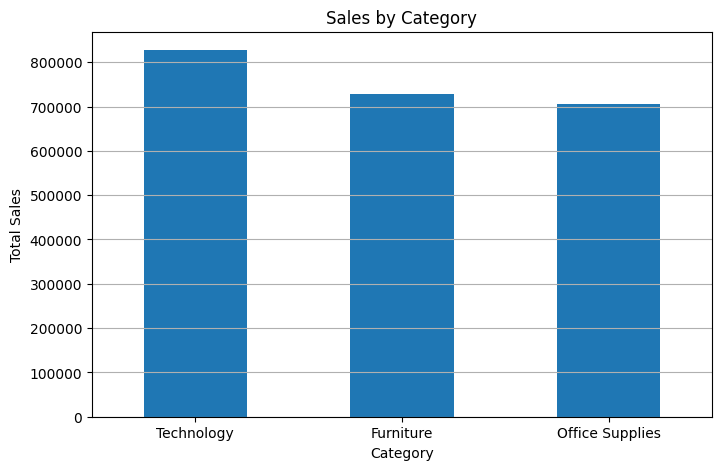

In [ ]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

**Find the highest-selling region**

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


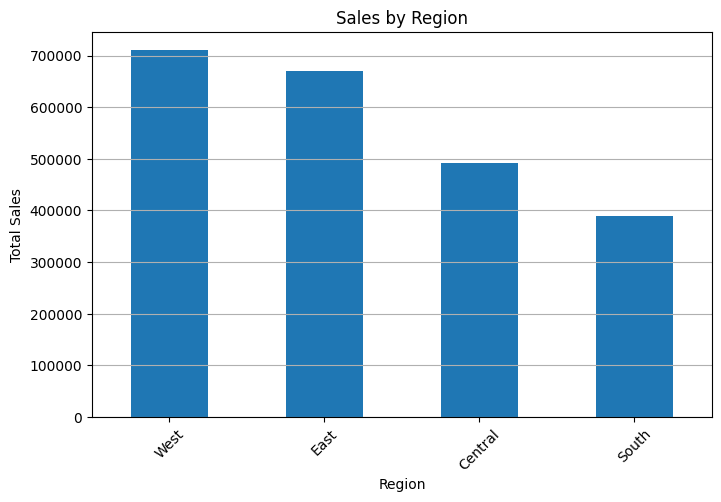

In [ ]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

**Find the best-selling products**

In [ ]:
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

print("Top 10 Products:")
print(product_sales.head(10))

Top 10 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


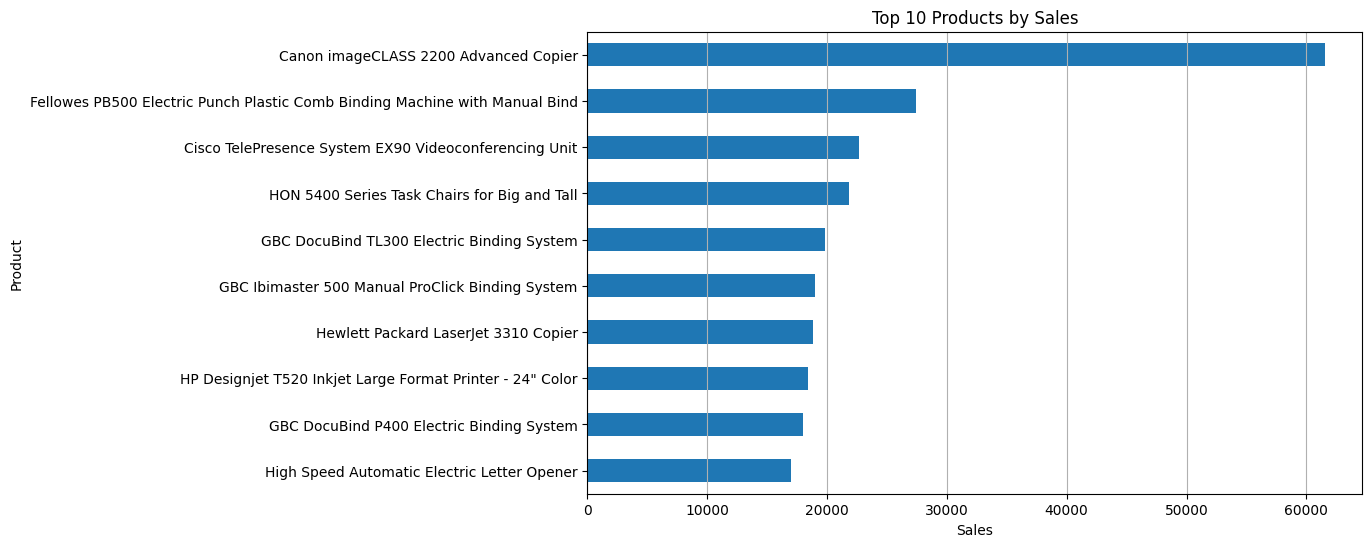

In [ ]:
plt.figure(figsize=(10, 6))

product_sales.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.grid(axis='x')

plt.show()

**Find the overall sales**

In [ ]:
total_sales = df['Sales'].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,261,536.78


**Get the best sales month**

In [ ]:
best_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax()
]

print("Best Sales Month:", best_month['Order Date'].strftime('%B %Y'))
print(f"Sales: ${best_month['Sales']:,.2f}")

Best Sales Month: November 2018
Sales: $117,938.15


**Final Project Summary**

In [ ]:
print("========== TASK 3 SUMMARY ==========")

print(f"Total Sales: ${total_sales:,.2f}")

print(
    "Best Category:",
    category_sales.idxmax()
)

print(
    "Best Region:",
    region_sales.idxmax()
)

print(
    "Best Sales Month:",
    best_month['Order Date'].strftime('%B %Y')
)

print(
    f"Model MAE: {mae:,.2f}"
)

print(
    f"Model R² Score: {r2:.2f}"
)

print("====================================")

========== TASK 3 SUMMARY ==========
Total Sales: $2,261,536.78
Best Category: Technology
Best Region: West
Best Sales Month: November 2018
Model MAE: 18,560.29
Model R² Score: 0.03
